In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np


from envs import BuySellEnv, BaseStoppingEnv
from algorithms import QLearningAgent,QOptimalBehaviourAgent, linear_decay_schedule, LongstaffSchwartzAgentBuySell
from algorithms import QSuperGreedyAgent
from helpers import visualizer, PolicyEvaluator, PolicySnapshotCallback

In [20]:
test_env_small = BuySellEnv(
    n_states=5,
    max_time=10,
    holding_cost_per_step=0.2,
    transition_model="iid_gaussian",
)


test_env = BuySellEnv(
    n_states=20,
    max_time=15,
    holding_cost_per_step=0.5,
    transition_model="brownian",
    transition_params={"mu": 15, "sigma": 10},
)

### LSM Whoops Q-Learning for Buy-Sell Env : (

In [ ]:
from algorithms.longstaff_schwartz import LongstaffSchwartzAgent

# Create environment
env_lsm = BuySellEnv(
    n_states=25,
    max_time=30,
    holding_cost_per_step=0.5,
    transition_model="brownian",
    transition_params={"mu": 15, "sigma": 10},
)

# Get optimal policy for comparison
V_opt, policy_opt = env_lsm.solve_optimal_policy()

# Train LSM
print("Training LSM...")
lsm_agent = LongstaffSchwartzAgent(env=env_lsm, poly_degree=3, seed=42)
lsm_time = lsm_agent.train(n_paths=500, seed=42)
print(f"LSM training time: {lsm_time:.2f}s")

# Train Q-Learning for comparison
print("\nTraining Q-Learning...")
n_ep = 500000
sched = linear_decay_schedule(1.0, 0.1, n_ep)
cb = PolicySnapshotCallback(snapshot_interval=3000)
ql_agent = QLearningAgent(env=env_lsm, alpha_schedule=sched, epsilon_schedule=sched)
ql_agent.train(env=env_lsm, n_episodes=n_ep, callbacks=[cb], verbose=0)

# Get policies
policy_lsm = lsm_agent.get_policy()
policy_ql = ql_agent.get_policy()

print("\nEvaluating all policies...")

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 13.7491
  Buy (stop 1) accept rate: 51.20%
  Sell (stop 2) accept rate: 15.73%
Training LSM...
Phase 1: Computing optimal SELL policy (stops_left=1)...


  Sell phase: 100%|██████████| 29/29 [00:00<00:00, 3810.61it/s]


Phase 2: Computing optimal BUY policy (stops_left=2)...


  Buy phase: 100%|██████████| 29/29 [00:00<00:00, 3698.68it/s]

Training complete in 0.27s
  Buy policy accept rate: 47.45%
  Sell policy accept rate: 15.47%
LSM training time: 0.27s

Training Q-Learning...


Training:   0%|                                                      | 0/50000 [00:00<?, ?episode/s]


Evaluating all policies...


Evaluating Q-Learning: 100%|██████████| 2000/2000 [00:00<00:00, 11320.46it/s]



Evaluation Summary: Q-Learning
Episodes: 2000

Reward Statistics:
  Mean:         10.4883
  Std:           5.4610
  Sharpe:        1.9206
  Median:       10.5000
  Min:         -16.5000
  Max:          23.5000

Episode Length:
  Mean:            6.73
  Std:             5.52

Buy-Sell Specific Metrics:
  Completion rate:   97.95%
  Mean buy price:     10.0500
  Mean sell price:    21.9076
  Mean profit:        11.8576
  Mean holding time:     2.30



Evaluating LSM: 100%|██████████| 2000/2000 [00:00<00:00, 6921.71it/s]



Evaluation Summary: LSM
Episodes: 2000

Reward Statistics:
  Mean:         12.9733
  Std:           5.2300
  Sharpe:        2.4805
  Median:       13.5000
  Min:         -11.0000
  Max:          23.5000

Episode Length:
  Mean:           14.39
  Std:             9.45

Buy-Sell Specific Metrics:
  Completion rate:   94.20%
  Mean buy price:      7.4278
  Mean sell price:    22.8121
  Mean profit:        15.3843
  Mean holding time:     3.22



Evaluating Optimal (DP): 100%|██████████| 2000/2000 [00:00<00:00, 6921.44it/s]



Evaluation Summary: Optimal (DP)
Episodes: 2000

Reward Statistics:
  Mean:         12.9720
  Std:           4.8174
  Sharpe:        2.6927
  Median:       13.5000
  Min:         -15.5000
  Max:          23.0000

Episode Length:
  Mean:           13.67
  Std:             9.13

Buy-Sell Specific Metrics:
  Completion rate:   97.55%
  Mean buy price:      7.8883
  Mean sell price:    22.8216
  Mean profit:        14.9334
  Mean holding time:     3.27


Policy Comparison: Q-Learning vs LSM vs Optimal (DP)

Metric                      Q-Learning          LSM Optimal (DP)           Best
--------------------------------------------------------------------------------
Mean Reward                    10.4883      12.9733      12.9720            LSM
Std Reward                      5.4610       5.2300       4.8174   Optimal (DP)
Sharpe Ratio                    1.9206       2.4805       2.6927   Optimal (DP)
Median Reward                  10.5000      13.5000      13.5000            LSM
Mean Epis

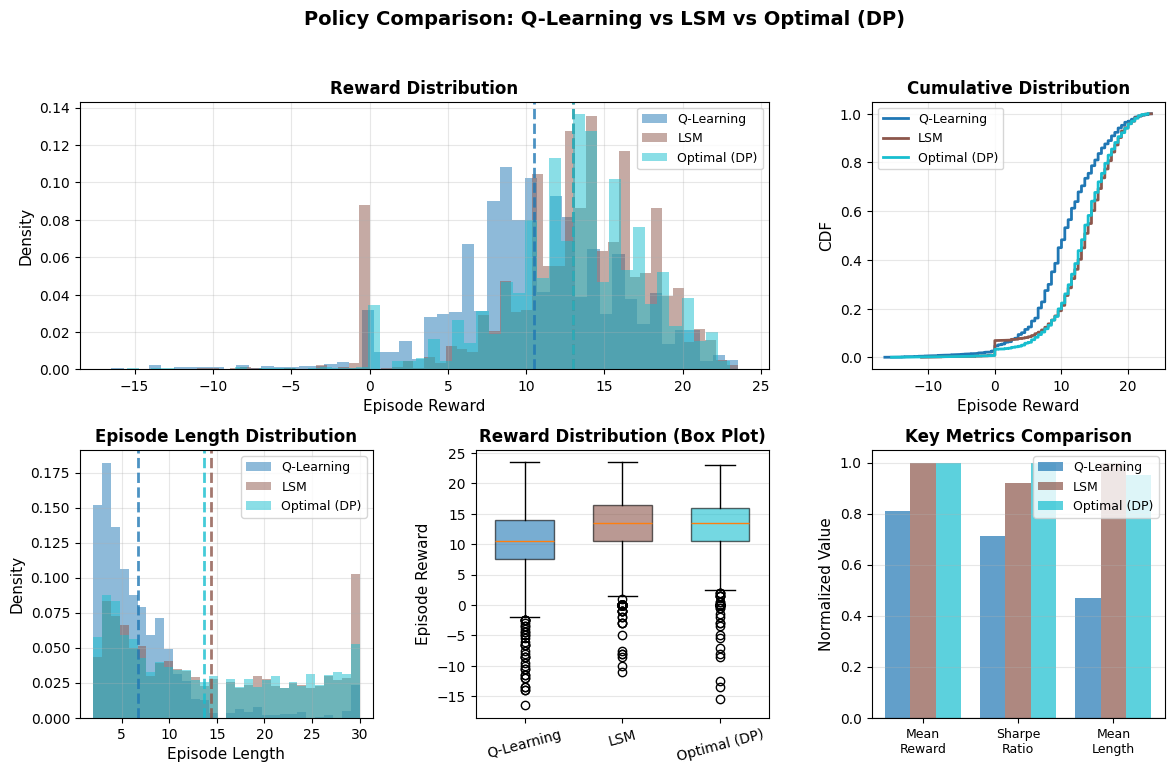

Evaluation complete.


In [ ]:
# Compare all methods
pe = PolicyEvaluator(env_lsm)
pe.compare_policies(
    policies=[policy_ql, policy_lsm, policy_opt],
    policy_names=["Q-Learning", "LSM", "Optimal (DP)"],
    n_episodes=2000
)
pe.plot_comparison()
print("Evaluation complete.")

LSM


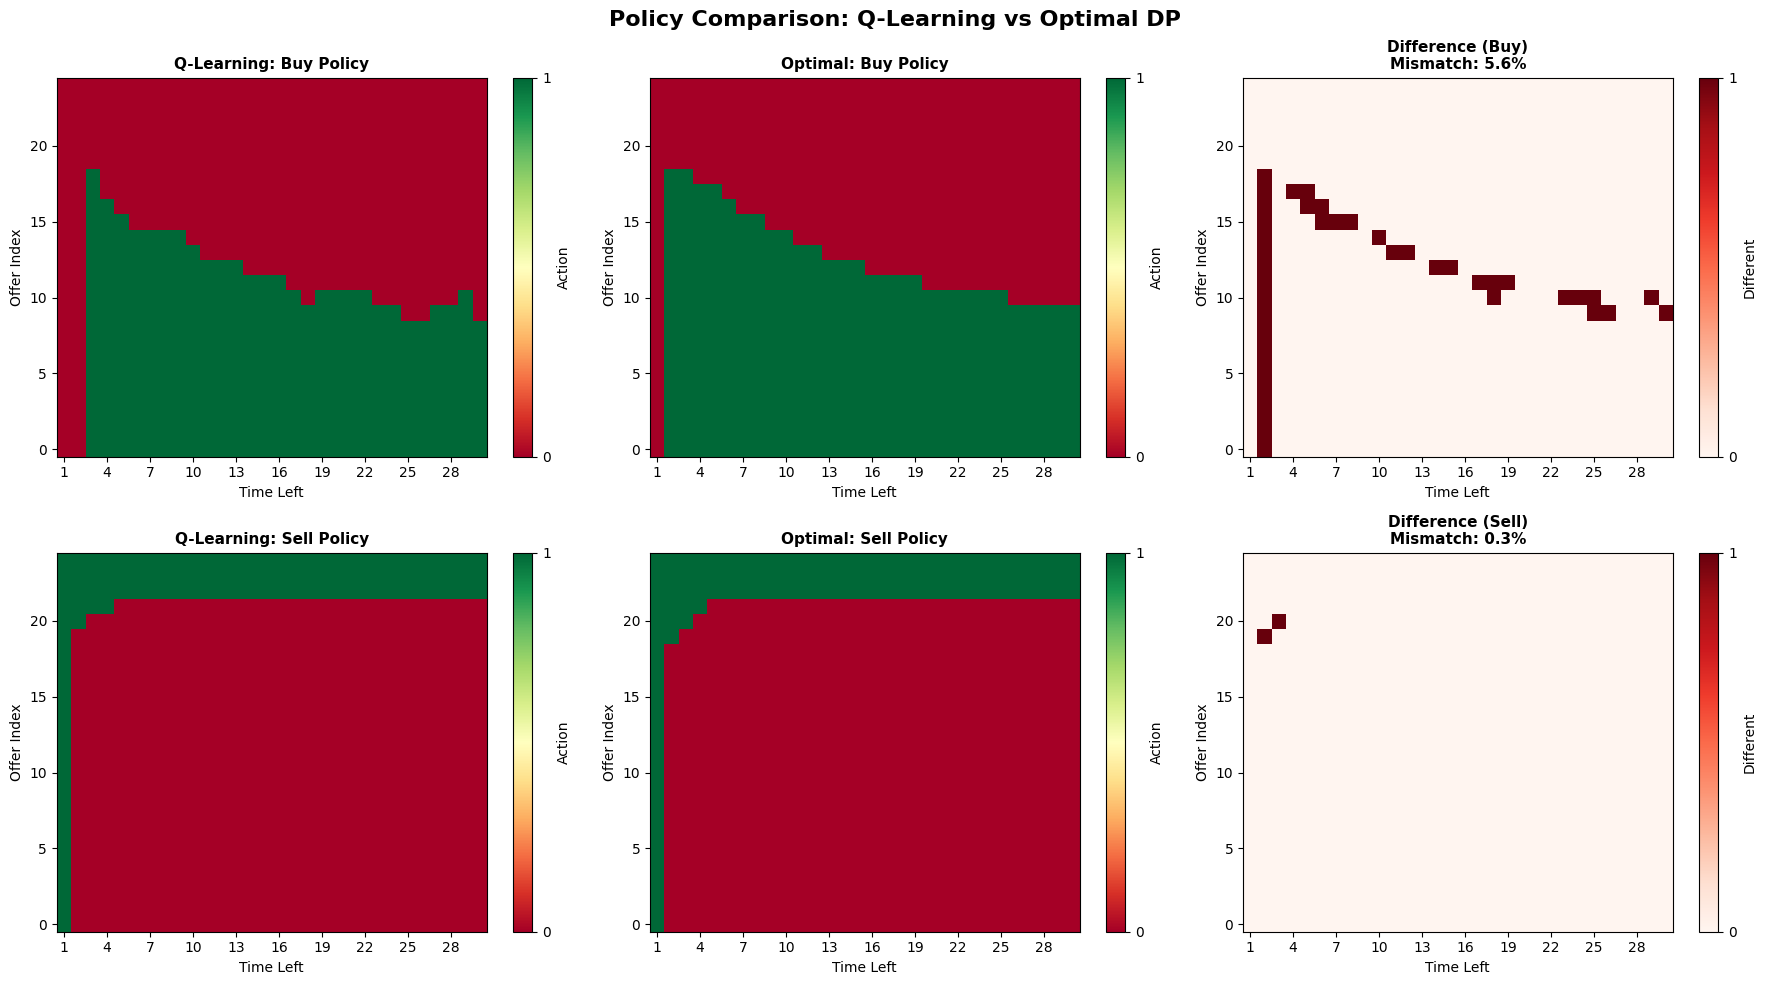


Policy Comparison Statistics

Buy Policy (stops_left=2):
  Q-Learning accept rate: 45.87%
  Optimal accept rate: 51.20%
  Agreement: 94.40%
  Mismatch: 5.60%

Sell Policy (stops_left=1):
  Q-Learning accept rate: 15.47%
  Optimal accept rate: 15.73%
  Agreement: 99.73%
  Mismatch: 0.27%

Overall Policy Agreement: 97.07%
QL


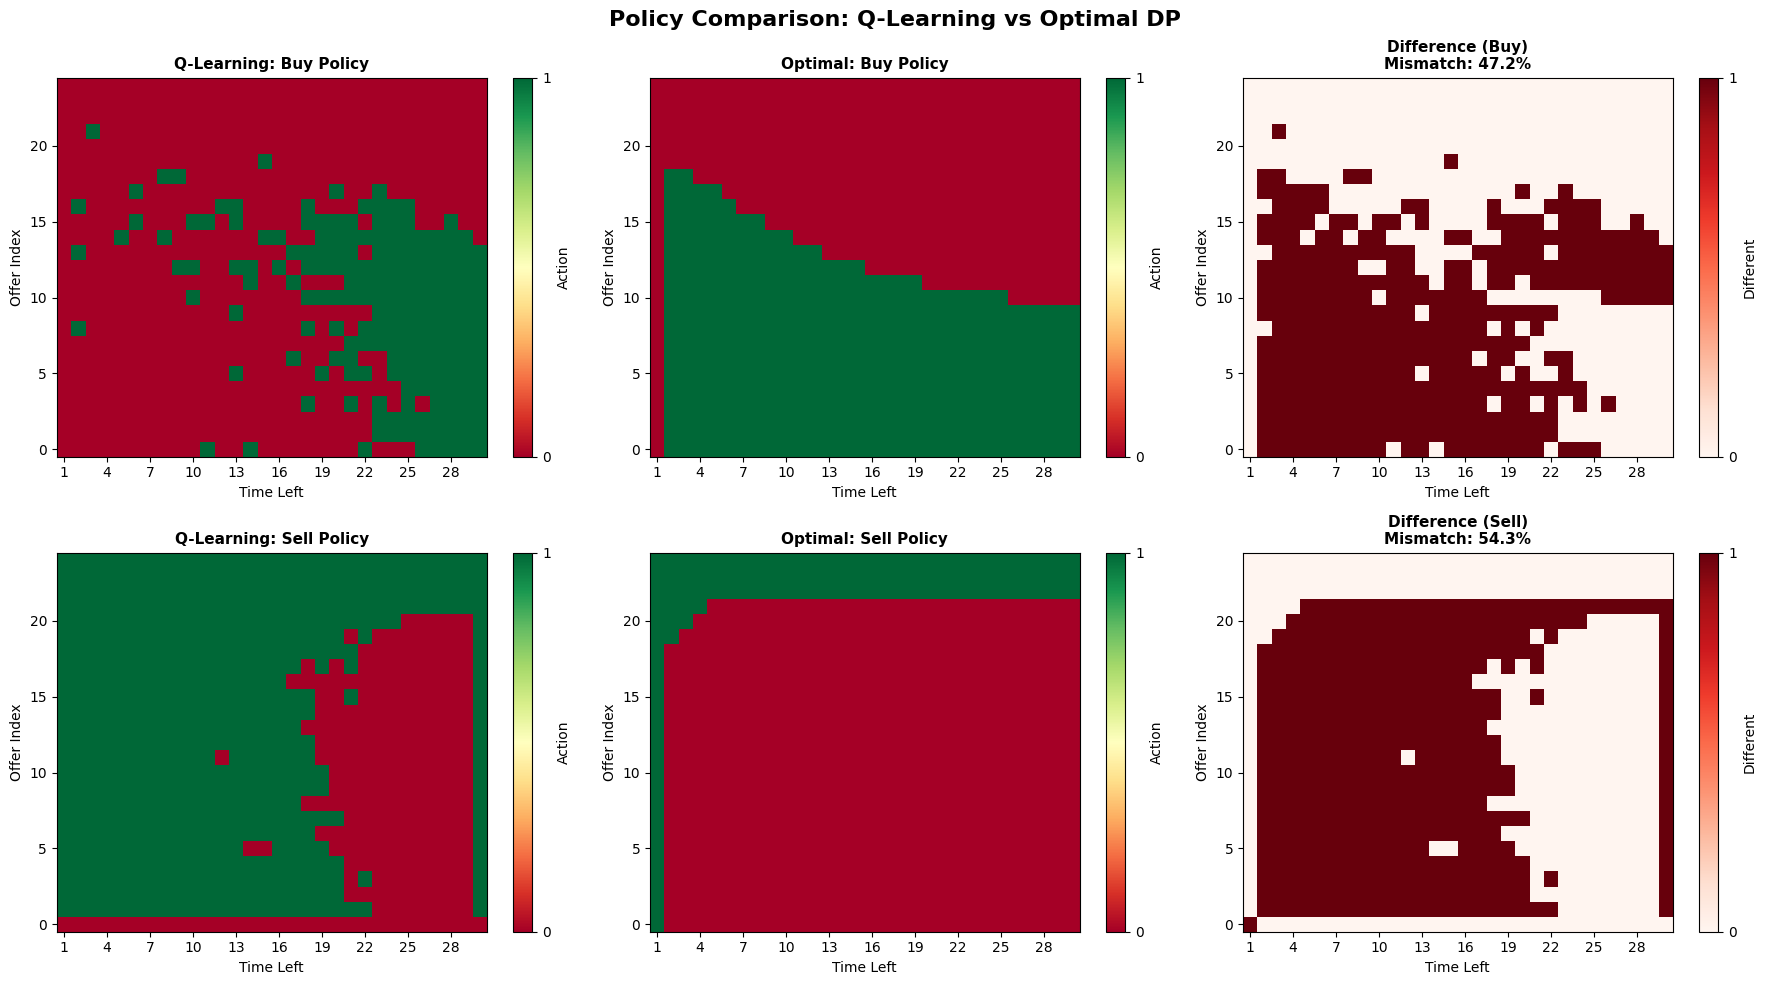


Policy Comparison Statistics

Buy Policy (stops_left=2):
  Q-Learning accept rate: 25.33%
  Optimal accept rate: 51.20%
  Agreement: 52.80%
  Mismatch: 47.20%

Sell Policy (stops_left=1):
  Q-Learning accept rate: 69.73%
  Optimal accept rate: 15.73%
  Agreement: 45.73%
  Mismatch: 54.27%

Overall Policy Agreement: 49.27%
Creating GIF with 17 frames...
  Rendered frame 10/17
  Rendered frame 17/17
✓ GIF saved to: policy_evolution.gif
  - 17 frames at 5 FPS
  - Duration: 3.4 seconds


'policy_evolution.gif'

In [ ]:
viz = visualizer(env_lsm, lsm_agent, optimal_policy=policy_opt, policy=policy_lsm, policy_provided=True)
print("="*70)
print("LSM which saw only 500 paths")
print("="*70)

viz.compare_with_optimal()

viz = visualizer(env_lsm, ql_agent, optimal_policy=policy_opt, policy_provided=False)
print("="*70)
print("QL which saw 5 lakh paths")
print("="*70)
viz.compare_with_optimal()
viz.create_policy_evolution_gif_with_callback(callback=cb, optimal_policy=policy_opt)   

In [ ]:
print("\nTraining Q-Learning...")
n_ep = 500000
sched = linear_decay_schedule(1.0, 0.1, n_ep)
cb = PolicySnapshotCallback(snapshot_interval=5000)
ql_agent = QLearningAgent(env=env_lsm, alpha_schedule=sched, epsilon_schedule=sched)
ql_agent.train(env=env_lsm, n_episodes=n_ep, callbacks=[cb], verbose=0)

# Get policies
policy_lsm = lsm_agent.get_policy()
policy_ql = ql_agent.get_policy()

viz = visualizer(env_lsm, ql_agent, optimal_policy=policy_opt, policy_provided=False)
viz.create_policy_evolution_gif_with_callback(callback=cb, optimal_policy=policy_opt)


Training Q-Learning...


Training:   0%|                                                     | 0/500000 [00:00<?, ?episode/s]

Creating GIF with 100 frames...
  Rendered frame 10/100
  Rendered frame 20/100
  Rendered frame 30/100
  Rendered frame 40/100
  Rendered frame 50/100
  Rendered frame 60/100
  Rendered frame 70/100
  Rendered frame 80/100
  Rendered frame 90/100
  Rendered frame 100/100
✓ GIF saved to: policy_evolution.gif
  - 100 frames at 5 FPS
  - Duration: 20.0 seconds


'policy_evolution.gif'

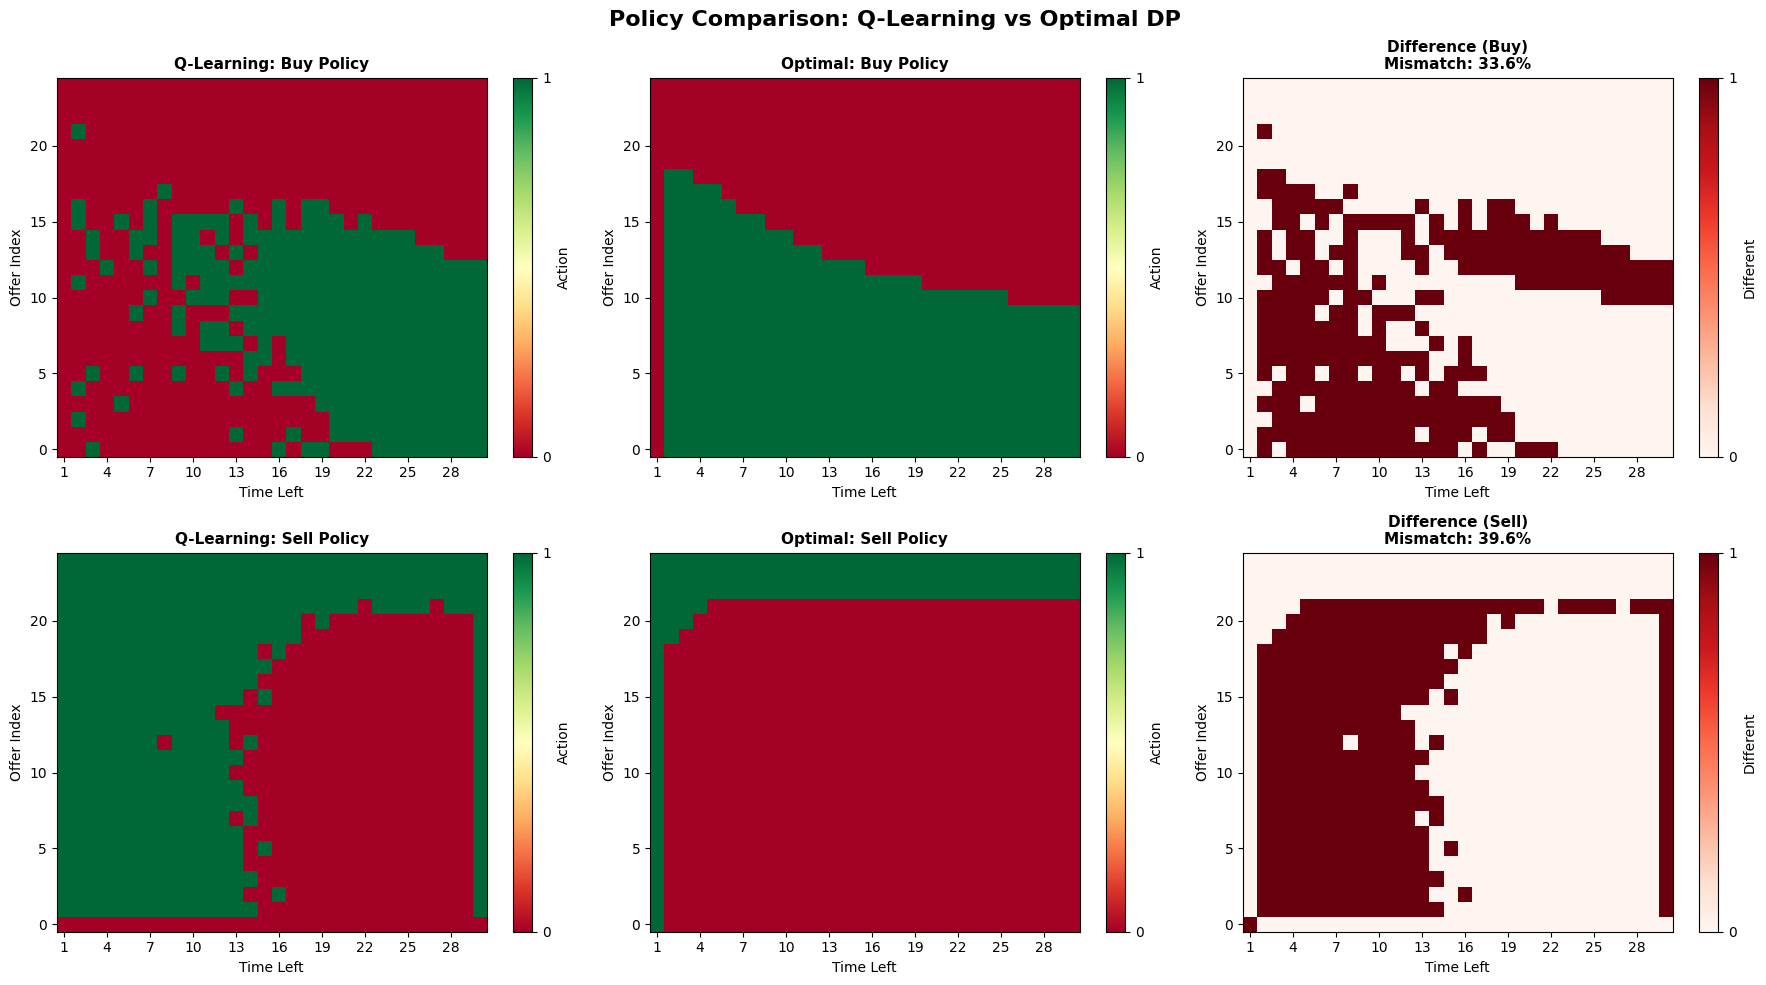


Policy Comparison Statistics

Buy Policy (stops_left=2):
  Q-Learning accept rate: 37.60%
  Optimal accept rate: 51.20%
  Agreement: 66.40%
  Mismatch: 33.60%

Sell Policy (stops_left=1):
  Q-Learning accept rate: 55.07%
  Optimal accept rate: 15.73%
  Agreement: 60.40%
  Mismatch: 39.60%

Overall Policy Agreement: 63.40%


In [ ]:
viz.compare_with_optimal()

In [3]:
n_ep = 50000
sched = linear_decay_schedule(1.0, 0.1, n_ep)
agent = QSuperGreedyAgent(env=test_env_small, alpha_schedule=sched, epsilon_schedule=sched)
agent.train(env=test_env_small, n_episodes=n_ep, verbose=1)


Training:   0%|                                                      | 0/50000 [00:00<?, ?episode/s]

{'episode_rewards': [np.float64(3.2),
  np.float64(1.8),
  np.float64(2.8),
  np.float64(2.6),
  np.float64(1.6),
  np.float64(3.6),
  np.float64(2.8),
  np.float64(2.8),
  np.float64(3.2),
  np.float64(2.0),
  np.float64(2.4),
  np.float64(2.8),
  np.float64(1.8),
  np.float64(2.0),
  np.float64(2.6),
  np.float64(2.6),
  np.float64(2.8),
  np.float64(1.8),
  np.float64(2.8),
  np.float64(2.8),
  np.float64(3.4),
  np.float64(2.8),
  np.float64(2.4),
  np.float64(3.2),
  np.float64(3.6),
  np.float64(3.6),
  np.float64(1.6),
  np.float64(1.8),
  np.float64(2.6),
  np.float64(2.8),
  np.float64(3.0),
  np.float64(2.2),
  np.float64(1.8),
  np.float64(2.6),
  np.float64(3.6),
  np.float64(1.8),
  np.float64(2.0),
  np.float64(2.8),
  np.float64(3.2),
  np.float64(1.8),
  np.float64(3.8),
  np.float64(1.8),
  np.float64(1.6),
  np.float64(2.8),
  np.float64(1.6),
  np.float64(2.8),
  np.float64(2.8),
  np.float64(1.8),
  np.float64(1.8),
  np.float64(1.8),
  np.float64(3.6),
  np.float64

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 2.0259
  Buy (stop 1) accept rate: 42.00%
  Sell (stop 2) accept rate: 46.00%


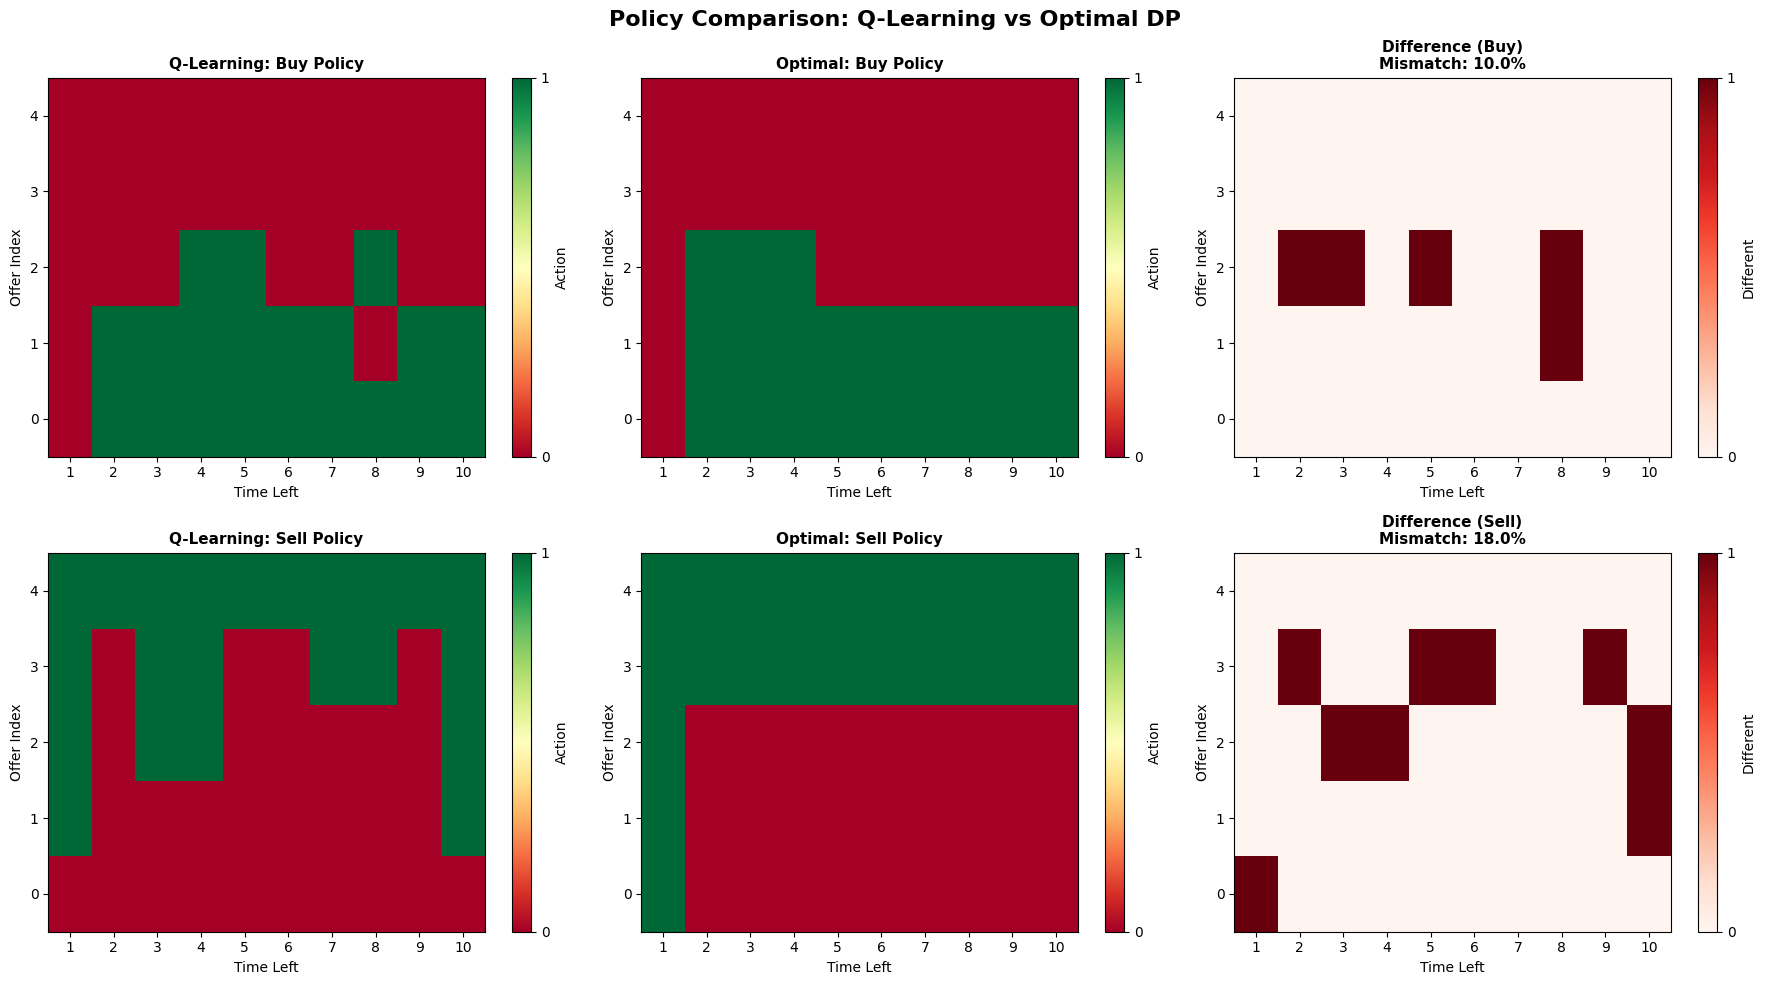


Policy Comparison Statistics

Buy Policy (stops_left=2):
  Q-Learning accept rate: 40.00%
  Optimal accept rate: 42.00%
  Agreement: 90.00%
  Mismatch: 10.00%

Sell Policy (stops_left=1):
  Q-Learning accept rate: 44.00%
  Optimal accept rate: 46.00%
  Agreement: 82.00%
  Mismatch: 18.00%

Overall Policy Agreement: 86.00%


In [4]:
vis = visualizer(test_env_small, agent, optimal_policy=None, policy_provided=False)
vis.compare_with_optimal()

Training:   0%|                                                      | 0/50000 [00:00<?, ?episode/s]

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 2.0259
  Buy (stop 1) accept rate: 42.00%
  Sell (stop 2) accept rate: 46.00%


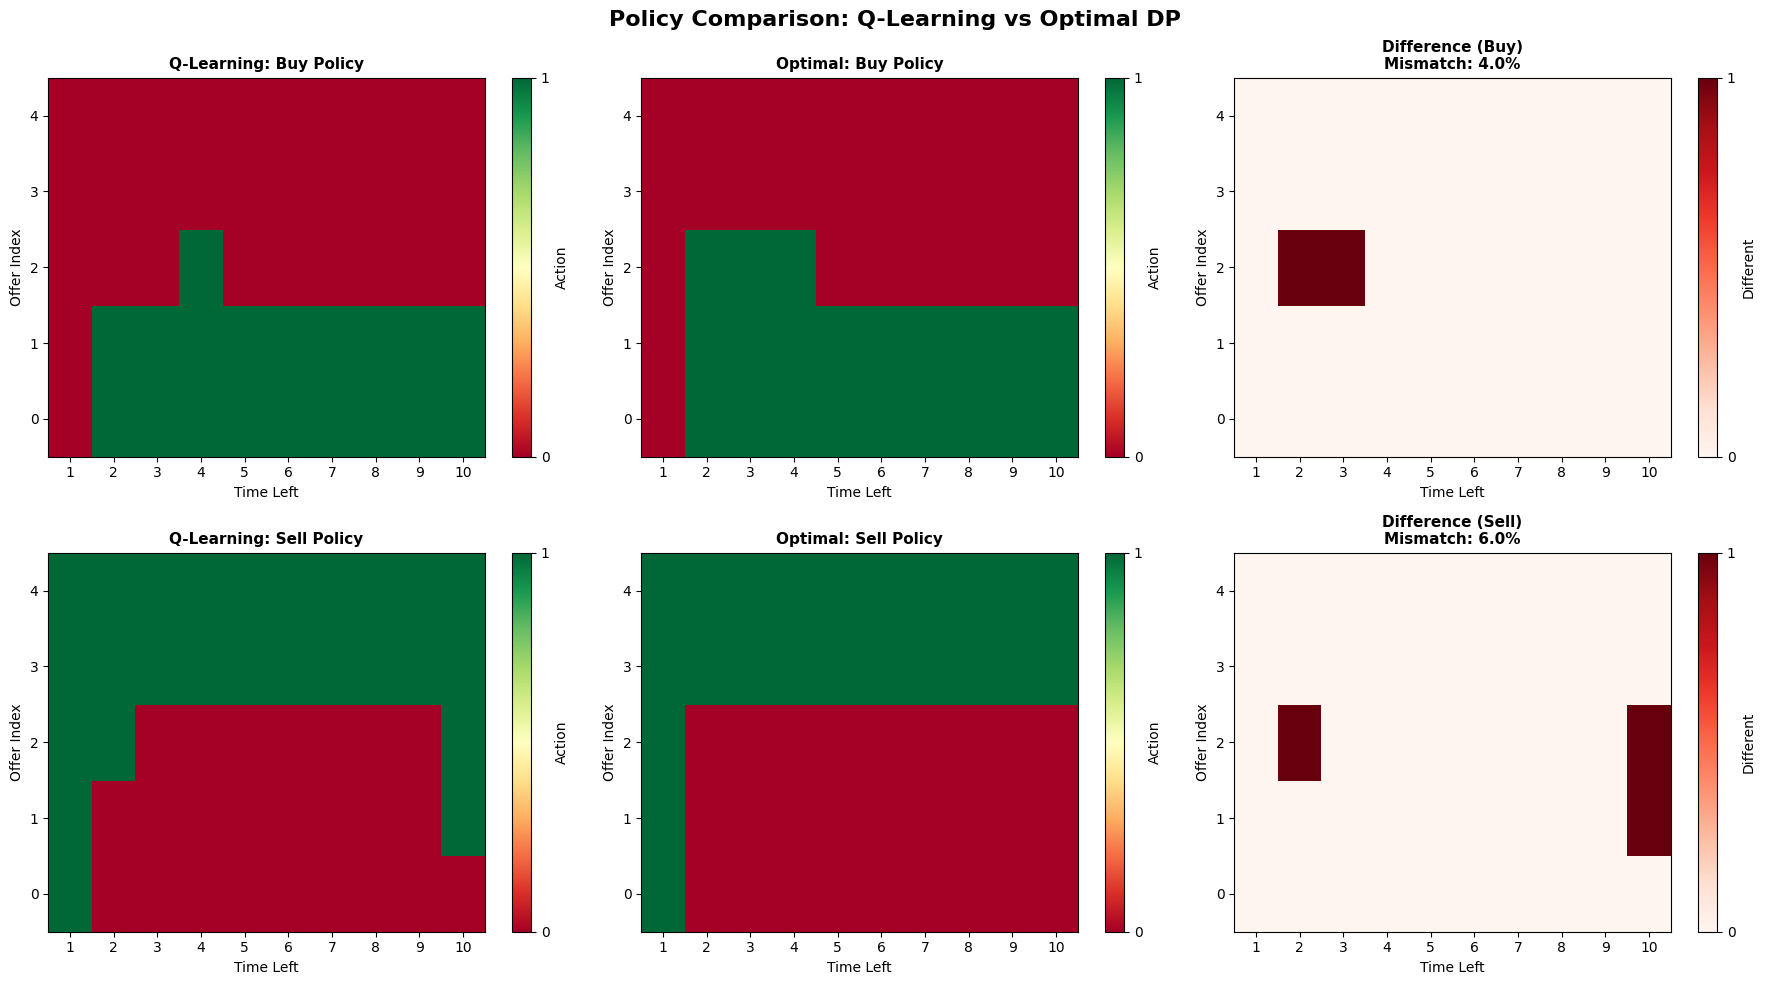


Policy Comparison Statistics

Buy Policy (stops_left=2):
  Q-Learning accept rate: 38.00%
  Optimal accept rate: 42.00%
  Agreement: 96.00%
  Mismatch: 4.00%

Sell Policy (stops_left=1):
  Q-Learning accept rate: 52.00%
  Optimal accept rate: 46.00%
  Agreement: 94.00%
  Mismatch: 6.00%

Overall Policy Agreement: 95.00%


In [5]:
agent2 = QLearningAgent(env=test_env_small, alpha_schedule=sched, epsilon_schedule=sched)
agent2.train(env=test_env_small, n_episodes=n_ep, verbose=1)
vis2 = visualizer(test_env_small, agent2, optimal_policy=None, policy_provided=False)
vis2.compare_with_optimal()


### But, Can LSM do better in online setting : Online Regret Tracking

Below I implement **true online regret**: track regret *during* the learning process itself.

- **Q-Learning**: Updates Q-values after each episode, so we track regret at every step
- **LSM**: Batch method - we simulate "online" by accumulating paths and periodically retraining

In [3]:
# =============================================================================
# TRUE ONLINE REGRET EXPERIMENT
# =============================================================================
from helpers.evaluator import OnlineRegretExperiment

# Environment setup (smaller for faster experiments)
env_online = BuySellEnv(
    n_states=15,
    max_time=20,
    holding_cost_per_step=0.3,
    transition_model="brownian",
    transition_params={"mu": 8, "sigma": 5},
)

# Get optimal policy
V_opt_online, policy_opt_online = env_online.solve_optimal_policy()
print("Optimal policy computed.")
print(f"Optimal value at start: {V_opt_online[env_online.n_states//2, env_online.max_time, env_online.max_stops]:.4f}")

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 7.1189
  Buy (stop 1) accept rate: 62.67%
  Sell (stop 2) accept rate: 18.00%
Optimal policy computed.
Optimal value at start: 5.7603


In [8]:
# =============================================================================
# Run Online Regret Experiment
# =============================================================================

N_ONLINE_EPISODES = 300

# Initialize experiment
online_exp = OnlineRegretExperiment(env_online, policy_opt_online)

# 1. Q-Learning Online
print("Running Q-Learning online...")
ql_agent_online = QLearningAgent(
    env=env_online,
    alpha_schedule=linear_decay_schedule(0.5, 0.05, N_ONLINE_EPISODES),
    epsilon_schedule=linear_decay_schedule(1.0, 0.1, N_ONLINE_EPISODES),
    gamma=1.0,
    seed=42
)
online_exp.run_qlearning_online(ql_agent_online, N_ONLINE_EPISODES, name="Q-Learning", seed=42)

# 2. LSM Online (with different retrain intervals)
print("\nRunning LSM online (retrain every 100 episodes)...")
online_exp.run_lsm_online(
    LongstaffSchwartzAgentBuySell,
    n_episodes=N_ONLINE_EPISODES,
    retrain_interval=100,
    name="LSM (retrain@100)",
    seed=42,
    poly_degree=3
)

print("\nRunning LSM online (retrain every 50 episodes)...")
online_exp.run_lsm_online(
        LongstaffSchwartzAgentBuySell,
        n_episodes=N_ONLINE_EPISODES,
        retrain_interval=50,
        name="LSM (retrain@50)",
        seed=42,
        poly_degree=3
)
print("\nRunning LSM online (retrain every 25 episodes)...")
online_exp.run_lsm_online(
     LongstaffSchwartzAgentBuySell,
    n_episodes=N_ONLINE_EPISODES,
    retrain_interval=25,
    name="LSM (retrain@25)",
    seed=42,
    poly_degree=3

)


online_exp.random_policy_baseline(N_ONLINE_EPISODES, name="Random Policy", seed=42)  
print("\nDone!")

Running Q-Learning online...


Online Q-Learning: 100%|██████████| 300/300 [00:00<00:00, 3753.83it/s]



Running LSM online (retrain every 100 episodes)...


Online LSM (retrain@100): 100%|██████████| 300/300 [00:00<00:00, 1716.07it/s]



Running LSM online (retrain every 50 episodes)...


Online LSM (retrain@50): 100%|██████████| 300/300 [00:00<00:00, 1026.83it/s]



Running LSM online (retrain every 25 episodes)...


Online Random Policy: 100%|██████████| 300/300 [00:00<00:00, 5595.79it/s]


Done!


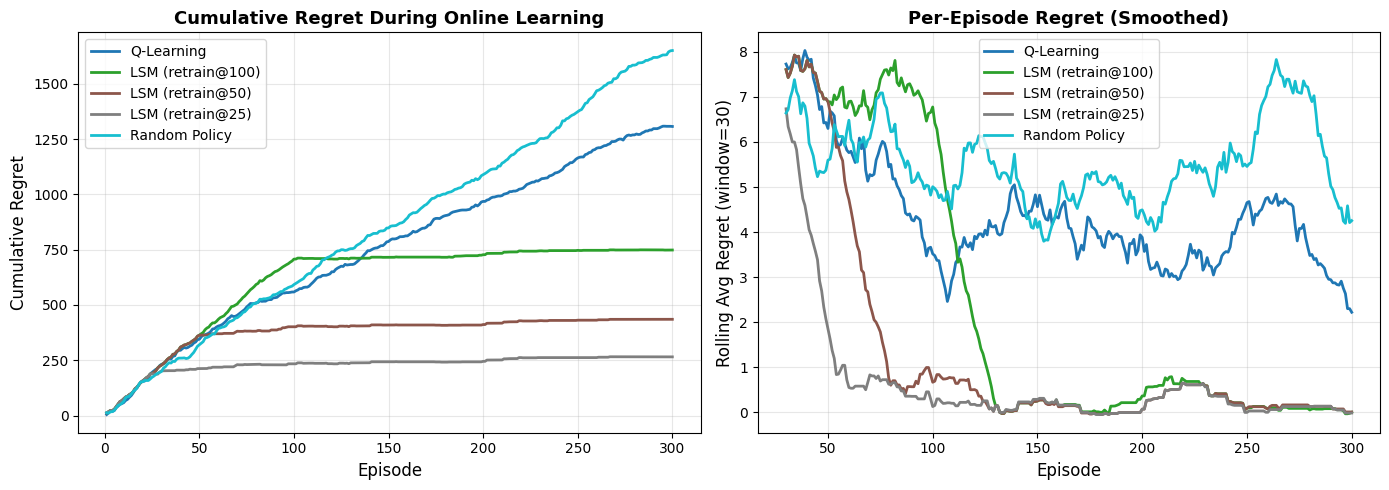


ONLINE REGRET SUMMARY
Agent                   Total Regret    Mean/Episode   Final 100 Avg
----------------------------------------------------------------------
LSM (retrain@25)              265.30          0.8843          0.2020
LSM (retrain@50)              435.20          1.4507          0.2370
LSM (retrain@100)             748.50          2.4950          0.2120
Q-Learning                   1307.20          4.3573          3.3890
Random Policy                1650.60          5.5020          5.6130


In [9]:
online_exp.plot_results()
online_exp.print_summary()

### Comparing LSM Continuation Values with Optimal Q(s, continue)

LSM uses regression to estimate **E[Y|X]** - the expected continuation value given current state.
This is exactly **Q(state, action=continue)** in the DP formulation.

We'll compare:
1. LSM's regression estimate: `basis(s) @ coefficients`
2. Optimal Q(s, continue) from DP: `reward_continue + sum_s' P(s'|s) * V(s', t-1, stops)`

For **sell phase (stops_left=1)**: Q(s, continue) = -holding_cost + E[V(s', t-1, 1)]
For **buy phase (stops_left=2)**: Q(s, continue) = E[V(s', t-1, 2)]

In [21]:
# =============================================================================
# COMPARE LSM E[Y|X] WITH OPTIMAL Q(s, continue)
# =============================================================================

import matplotlib.pyplot as plt

# Use the small test environment
env = test_env
V_opt, Q_opt, policy_opt = env.solve_optimal_policy()
# Q_opt shape: (n_states, max_time+1, max_stops+1, 2)
# Q_opt[s, t, stops, 0] = Q(continue), Q_opt[s, t, stops, 1] = Q(stop)

# Train LSM
lsm = LongstaffSchwartzAgentBuySell(env=env, poly_degree=3, seed=42)
lsm.train(n_paths=1000, seed=42, verbose=True)

# Function to get LSM's continuation value estimate
def get_lsm_continuation_estimate(lsm, state, time_left, stops_left):
    """
    Get LSM's regression estimate of E[Y|X=state] for given (time_left, stops_left).
    """
    key = (stops_left, time_left)
    if key not in lsm.regression_models or lsm.regression_models[key] is None:
        return np.nan
    
    coeffs = lsm.regression_models[key]
    basis = lsm._basis_functions(np.array([state]))
    return (basis @ coeffs)[0]

print("Environment parameters:")
print(f"  n_states: {env.n_states}, max_time: {env.max_time}")
print(f"  holding_cost: {env.holding_cost_per_step}")
print(f"  Q_opt shape: {Q_opt.shape}  # (states, time, stops, actions)")
print(f"  offer_values: {env.offer_values}")

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 10.2256
  Buy (stop 1) accept rate: 51.67%
  Sell (stop 2) accept rate: 22.33%
Phase 1: Computing optimal SELL policy (stops_left=1)...


  Sell phase: 100%|██████████| 14/14 [00:00<00:00, 3437.15it/s]


Phase 2: Computing optimal BUY policy (stops_left=2)...


  Buy phase: 100%|██████████| 14/14 [00:00<00:00, 1140.15it/s]

Training complete in 0.17s
  Buy policy accept rate: 46.43%
  Sell policy accept rate: 22.33%
Environment parameters:
  n_states: 20, max_time: 15
  holding_cost: 0.5
  Q_opt shape: (20, 16, 3, 2)  # (states, time, stops, actions)
  offer_values: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]


SELL PHASE (stops_left=1): Q(s, continue)


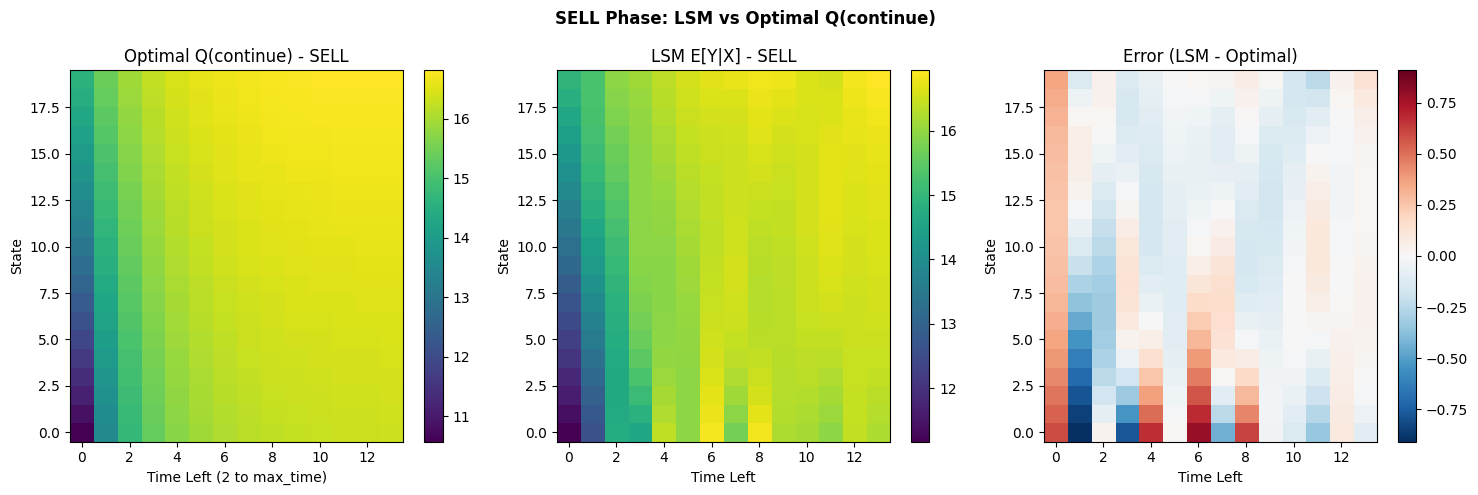

SELL Phase - MAE: 0.1454, Max|Err|: 0.9075


In [22]:
# =============================================================================
# HEATMAP: SELL PHASE (stops_left=1)
# =============================================================================

print("="*70)
print("SELL PHASE (stops_left=1): Q(s, continue)")
print("="*70)

# Extract Q(continue) for sell phase: Q_opt[s, t, 1, 0]
# time_left from 2 to max_time (indices 2:max_time+1)
Q_opt_sell_continue = Q_opt[:, 2:, 1, 0]  # shape: (n_states, max_time-1)

# Get LSM estimates for same (state, time_left) pairs
n_times = env.max_time - 1  # time_left from 2 to max_time
Q_lsm_sell_continue = np.zeros((env.n_states, n_times))
for i, t in enumerate(range(2, env.max_time + 1)):
    for s in range(env.n_states):
        Q_lsm_sell_continue[s, i] = get_lsm_continuation_estimate(lsm, s, t, 1)

Error_sell = Q_lsm_sell_continue - Q_opt_sell_continue

# Create heatmaps
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im1 = axes[0].imshow(Q_opt_sell_continue, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Optimal Q(continue) - SELL')
axes[0].set_xlabel('Time Left (2 to max_time)')
axes[0].set_ylabel('State')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(Q_lsm_sell_continue, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('LSM E[Y|X] - SELL')
axes[1].set_xlabel('Time Left')
axes[1].set_ylabel('State')
plt.colorbar(im2, ax=axes[1])

vmax = np.nanmax(np.abs(Error_sell))
im3 = axes[2].imshow(Error_sell, aspect='auto', origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[2].set_title('Error (LSM - Optimal)')
axes[2].set_xlabel('Time Left')
axes[2].set_ylabel('State')
plt.colorbar(im3, ax=axes[2])

plt.suptitle('SELL Phase: LSM vs Optimal Q(continue)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"SELL Phase - MAE: {np.nanmean(np.abs(Error_sell)):.4f}, Max|Err|: {np.nanmax(np.abs(Error_sell)):.4f}")

BUY PHASE (stops_left=2): Q(s, continue)


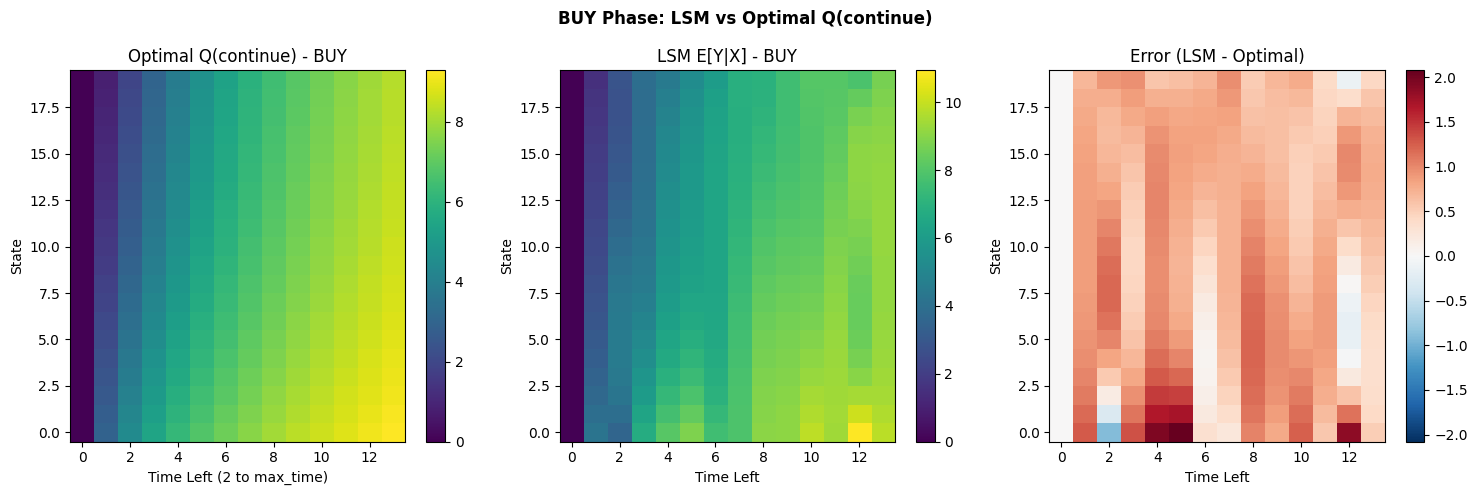

BUY Phase - MAE: 0.7041, Max|Err|: 2.0783


In [23]:
# =============================================================================
# HEATMAP: BUY PHASE (stops_left=2)
# =============================================================================

print("="*70)
print("BUY PHASE (stops_left=2): Q(s, continue)")
print("="*70)

# Extract Q(continue) for buy phase: Q_opt[s, t, 2, 0]
Q_opt_buy_continue = Q_opt[:, 2:, 2, 0]  # shape: (n_states, max_time-1)

# Get LSM estimates
Q_lsm_buy_continue = np.zeros((env.n_states, n_times))
for i, t in enumerate(range(2, env.max_time + 1)):
    for s in range(env.n_states):
        Q_lsm_buy_continue[s, i] = get_lsm_continuation_estimate(lsm, s, t, 2)

Error_buy = Q_lsm_buy_continue - Q_opt_buy_continue

# Create heatmaps
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im1 = axes[0].imshow(Q_opt_buy_continue, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Optimal Q(continue) - BUY')
axes[0].set_xlabel('Time Left (2 to max_time)')
axes[0].set_ylabel('State')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(Q_lsm_buy_continue, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('LSM E[Y|X] - BUY')
axes[1].set_xlabel('Time Left')
axes[1].set_ylabel('State')
plt.colorbar(im2, ax=axes[1])

vmax = np.nanmax(np.abs(Error_buy))
im3 = axes[2].imshow(Error_buy, aspect='auto', origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[2].set_title('Error (LSM - Optimal)')
axes[2].set_xlabel('Time Left')
axes[2].set_ylabel('State')
plt.colorbar(im3, ax=axes[2])

plt.suptitle('BUY Phase: LSM vs Optimal Q(continue)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"BUY Phase - MAE: {np.nanmean(np.abs(Error_buy)):.4f}, Max|Err|: {np.nanmax(np.abs(Error_buy)):.4f}")